In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


# Problem 1

$$\min e^{x_1 - 1} + e^{-x_1 + 1} + e^{x_2-2} + e^{-x_2 +2 } + e^{-x_3 + 3} + (x_1 + 2x_2 +5x_3)^4$$

In [2]:
# Write a code in CVX to find the global minimum x*

x1 = cp.Variable()
x2 = cp.Variable()
x3 = cp.Variable()

objective = cp.Minimize(
    cp.exp(x1-1) + cp.exp(-x1+1) +
    cp.exp(x2-2) + cp.exp(-x2+2) +
    cp.exp(x3-3) + cp.exp(-x3+3) +
    x1 - 2*x2 + 5*x3
)

problem = cp.Problem(objective)
problem.solve()

x1_cp = x1.value
x2_cp = x2.value
x3_cp = x3.value

print(f"CVXPY Solution: x1 = {x1_cp}, x2 = {x2_cp}, x3 = {x3_cp}")

CVXPY Solution: x1 = 0.5187978642407234, x2 = 2.8814330946767543, x3 = 1.3527731223064692


In [3]:
# Then, write a code that implements the Gradient method with your choice of the backtracking parameters. 

# randomly choose for when k = 0
x1 = 1
x2 = 1
x3 = 1

t = 0.1

arr_g = []
arr_g.append([x1, x2, x3])

for i in range(50):
    x1_new = x1 - t * (np.exp(x1-1) - np.exp(-x1+1) + 1)
    x2_new = x2 - t * (np.exp(x2-2) - np.exp(-x2+2) - 2)
    x3_new = x3 - t * (np.exp(x3-3) - np.exp(-x3+3) + 5)
    arr_g.append([x1_new, x2_new, x3_new])
    x1, x2, x3 = x1_new, x2_new, x3_new
    

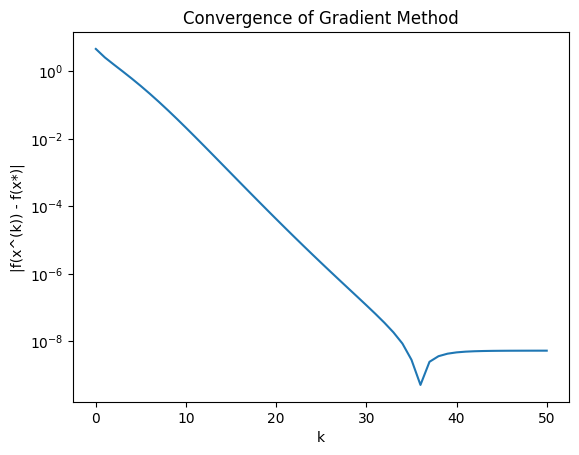

In [4]:
# Draw |f(x(k)) − f(x∗)| verses k for k = 0, 1, 2, . . . , 50 on alog-linear plot. 
# Show the trajectory of the points x(0), x(1), ..., x(50) in the 3-dimensional (x1, x2, x3) plane.

def f(x):
    x1, x2, x3 = x
    return (np.exp(x1-1) + np.exp(-x1+1) + np.exp(x2-2) + np.exp(-x2+2) + np.exp(x3-3) + np.exp(-x3+3) + x1 - 2*x2 + 5*x3)

f_vals = np.array([f(x) for x in arr_g])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_g))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Gradient Method")

plt.show()

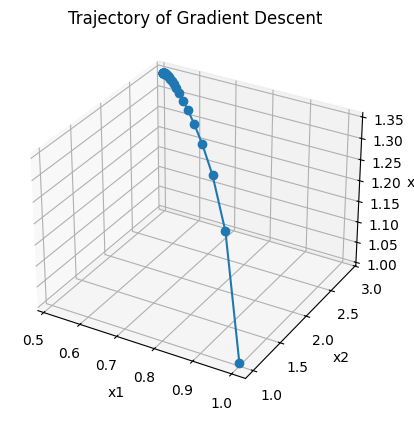

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

arr_g = np.array(arr_g)

ax.plot(arr_g[:,0], arr_g[:,1], arr_g[:,2], marker="o")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Gradient Descent")

plt.show()

\newpage

# Problem 2
Redo the previous problem with Newton’s method.

In [10]:
x = np.array([1.0, 2.0, 3.0])

arr_n = []
arr_n.append(x)

alpha = 0.25
beta = 0.5

def f(x):
    x1, x2, x3 = x
    return (np.exp(x1-1) + np.exp(-x1+1) + np.exp(x2-2) + np.exp(-x2+2) + np.exp(x3-3) + np.exp(-x3+3) + x1 - 2*x2 + 5*x3)

for i in range(50):
    hessian = np.diag([
        np.exp(x[0]-1) + np.exp(-x[0]+1),
        np.exp(x[1]-2) + np.exp(-x[1]+2),
        np.exp(x[2]-3) + np.exp(-x[2]+3)
    ])
    gradient = np.array([
        np.exp(x[0]-1) - np.exp(-x[0]+1) + 1,
        np.exp(x[1]-2) - np.exp(-x[1]+2) - 2,
        np.exp(x[2]-3) - np.exp(-x[2]+3) + 5
    ])
    delta = np.linalg.solve(hessian, gradient)
    
    t = 1
    # backtracking line search
    while f(x - t * delta) > f(x) - alpha * t * gradient @ delta:
        t *= beta  # shrink step size

    # update x after line search
    x = x - t * delta
    arr_n.append(x.copy())

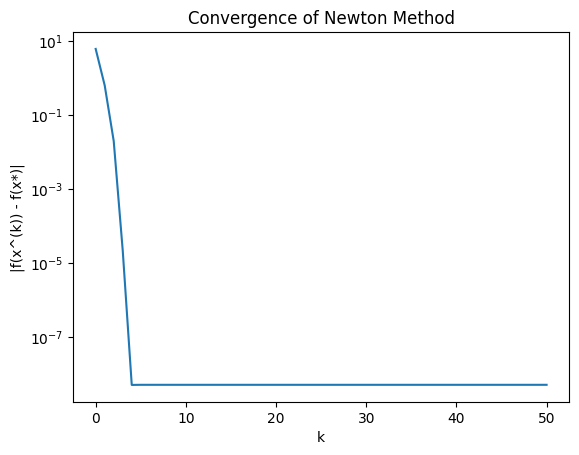

In [7]:
f_vals = np.array([f(x) for x in arr_n])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_n))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Newton Method")

plt.show()

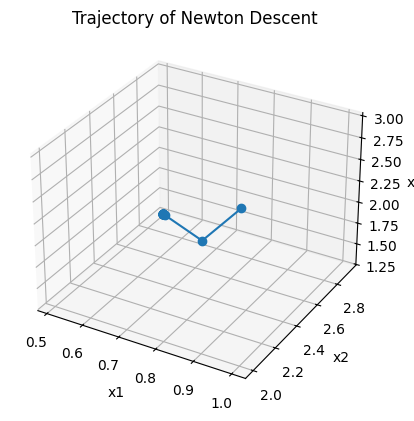

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

arr_n = np.array(arr_n)

ax.plot(arr_n[:,0], arr_n[:,1], arr_n[:,2], marker="o")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Newton Descent")

plt.show()

In [9]:
# 3 CVX
n = 2000

x = cp.Variable(n)

A = np.random.rand(n, n)

term1 = -cp.sum(cp.log(1 - cp.square(x)))

term2 = -cp.sum(cp.log(4 + A @ x))

objective = cp.Minimize(term1 + term2)

problem = cp.Problem(objective)
problem.solve()

x_star = x.value

print("Optimal value:", problem.value)
print("First 10 entries of x*:", x_star[:10])

Optimal value: -11920.195854659436
First 10 entries of x*: [0.57657004 0.57202131 0.57055443 0.5761408  0.58048394 0.5755389
 0.57147894 0.57391718 0.57632321 0.57525257]


In [13]:
# 3 Newton's 

x = np.ones(2000)

t = 0.1 # step size

arr_3n = []

arr_3n.append(x)

for i in range(100):
    hessian = [[np.exp(x1-1) + np.exp(-x1+1), 0, 0], 
           [0, np.exp(x2-2) + np.exp(-x2+2), 0], 
           [0, 0, np.exp(x3-3) + np.exp(-x3+3)]]
    gradient = [x1 - t * (np.exp(x1-1) - np.exp(-x1+1) + 1), 
                x2 - t * (np.exp(x2-2) - np.exp(-x2+2) - 2), 
                x3 - t * (np.exp(x3-3) - np.exp(-x3+3) + 5)]
    x_new = [x1, x2, x3] - t * (np.linalg.inv(hessian) @ gradient)
    arr_n.append(x_new)
    x1, x2, x3 = x_new[0], x_new[1], x_new[2]